In [ ]:
## Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Cargar el dataset
df = pd.read_csv("spotifydataset.csv")

## Mostrar las primeras filas
df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [ ]:
# Conocer las estructuras de los datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 non-null   i

In [ ]:
# Conocer las estadísticas descriptivas (promedio, desviación estándar, mínimo, máximo, etc.)
df.describe()


,Unnamed: 0,followers,artist_popularity,duration_ms,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,1.150655e+07,59.429000,212368.619000,59.429000,0.611430,0.660562,5.243000,-7.160373,0.613000,0.091402,0.265840,0.074700,0.188810,0.516641,122.143448
std,288.819436,2.293890e+07,23.884963,65706.472572,23.884963,0.167246,0.207568,3.613725,4.479642,0.487307,0.090441,0.288895,0.225472,0.145454,0.232896,28.053658
min,0.000000,2.000000e+00,0.000000,51680.000000,0.000000,0.069000,0.003540,0.000000,-39.482000,0.000000,0.023200,0.000005,0.000000,0.026000,0.032600,49.305000
25%,249.750000,1.038784e+06,57.000000,173083.000000,57.000000,0.505500,0.539500,2.000000,-8.334250,0.000000,0.037975,0.028325,0.000000,0.095700,0.343500,99.983500
50%,499.500000,3.923159e+06,67.000000,204382.500000,67.000000,0.634000,0.680500,5.000000,-5.943500,1.000000,0.054800,0.152500,0.000004,0.129000,0.522000,122.073500
75%,749.250000,1.142132e+07,74.000000,244192.750000,74.000000,0.728250,0.820000,9.000000,-4.582500,1.000000,0.106000,0.416250,0.000586,0.246500,0.686250,138.667250
max,999.000000,1.194287e+08,92.000000,707160.000000,92.000000,0.964000,0.998000,11.000000,0.273000,1.000000,0.874000,0.996000,0.972000,0.984000,0.973000,201.776000


In [ ]:
# Verificar valores nulos 
df.isnull().sum()

Unnamed: 0             0
artist_name            0
genres               163
followers              0
artist_popularity      0
artist_url             0
track_name             0
album_name             0
release_date           0
duration_ms            0
explicit               0
track_popularity       0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
dtype: int64

In [ ]:
# Seleccionar las columnas relevantes para el análisis
columnas = [
    "track_popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

datos = df[columnas].copy()

datos.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [ ]:
# Eliminar filas con valores nulos
datos = datos.dropna()
print("Número de registros:", len(datos))

Número de registros: 1000


In [ ]:
# Escalar los datos (normalización)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos)

In [ ]:
# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)

componentes = pca.fit_transform(datos_escalados)

pca_df = pd.DataFrame(componentes,
                      columns=["PC1","PC2"])

pca_df.head()

,PC1,PC2
0,0.063185,0.129111
1,0.609885,1.542816
2,-1.725773,1.120047
3,1.178713,-0.074323
4,1.060287,0.941007


In [ ]:
# Visualizar los datos en el espacio de las componentes principales
print("Varianza explicada por cada componente:")

print(pca.explained_variance_ratio_)

print()

print("Varianza acumulada:")

print(sum(pca.explained_variance_ratio_))

Varianza explicada por cada componente:
[0.24909434 0.12774645]

Varianza acumulada:
0.3768407900127038


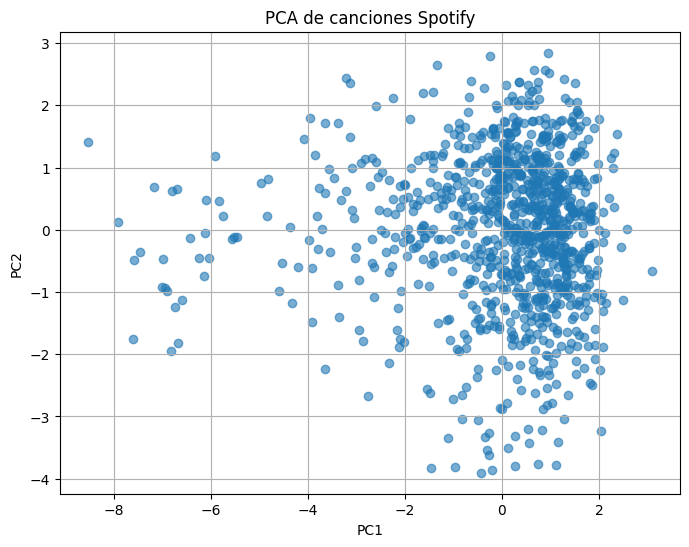

In [ ]:
# Visualización de los datos en el espacio de las componentes principales
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.title("PCA de canciones Spotify")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid()

plt.show()

Cada punto representa una canción. PCA redujo las 12 variables originales a dos componentes principales para facilitar la visualización. Las canciones cercanas presentan características acústicas similares.

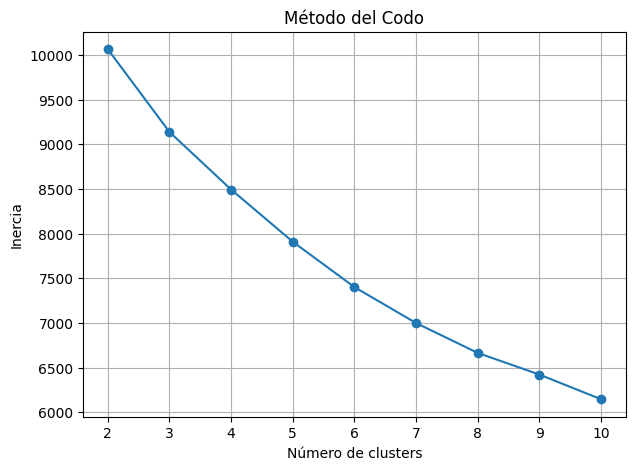

In [ ]:
# metodo del codo para determinar el número óptimo de clusters
inercias = []

for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(datos_escalados)

    inercias.append(modelo.inertia_)
plt.figure(figsize=(7,5))

plt.plot(range(2,11),inercias,"o-")

plt.xlabel("Número de clusters")

plt.ylabel("Inercia")

plt.title("Método del Codo")

plt.grid()

plt.show()

In [ ]:
# Aplicar K-Means para agrupar los datos
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(datos_escalados)

pca_df["Cluster"] = clusters

datos["Cluster"] = clusters

In [ ]:
# Visualización de los clusters en el espacio de las componentes principales
score = silhouette_score(datos_escalados,clusters)

print("Silhouette Score:",score)

Silhouette Score: 0.12674815897800823


In [ ]:
# como el número de clusters afecta el Silhouette Score
scores = []

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(datos_escalados)

    score = silhouette_score(datos_escalados, etiquetas)
    scores.append(score)

    print(f"K = {k} --> Silhouette = {score:.4f}")

K = 2 --> Silhouette = 0.2764
K = 3 --> Silhouette = 0.1220
K = 4 --> Silhouette = 0.1267
K = 5 --> Silhouette = 0.1258
K = 6 --> Silhouette = 0.1183
K = 7 --> Silhouette = 0.1200
K = 8 --> Silhouette = 0.1237
K = 9 --> Silhouette = 0.1209
K = 10 --> Silhouette = 0.1231


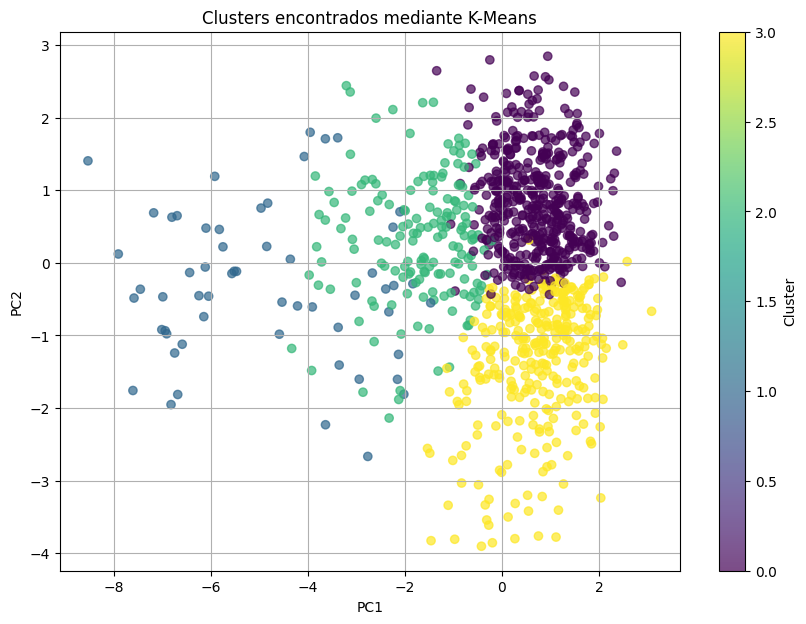

In [ ]:
# finalmente, visualizamos los clusters en el espacio de las componentes principales
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Clusters encontrados mediante K-Means")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.colorbar(label="Cluster")

plt.grid()

plt.show()

Los colores representan los clusters generados por K-Means. Cada grupo contiene canciones con características de audio similares.

In [ ]:
# Analizar las características promedio de cada cluster
datos.groupby("Cluster").mean().round(2)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,67.15,0.72,0.69,5.37,-6.10,0.49,0.10,0.21,0.00,0.15,0.63,114.95
1,40.79,0.44,0.30,4.72,-19.01,0.60,0.05,0.75,0.84,0.12,0.32,112.68
2,50.70,0.53,0.42,5.63,-9.97,0.75,0.08,0.61,0.03,0.14,0.39,116.21
3,55.81,0.52,0.81,4.95,-5.11,0.73,0.09,0.09,0.06,0.28,0.45,137.76


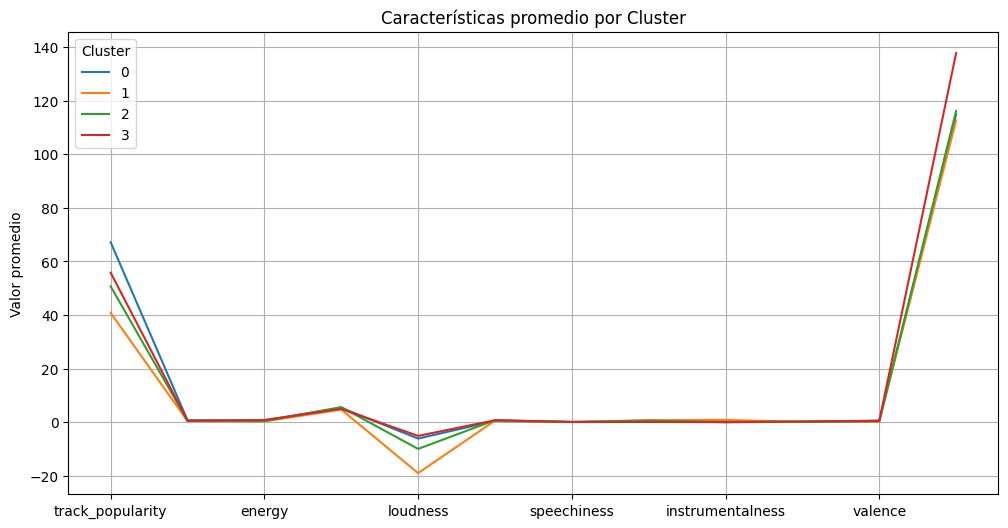

In [ ]:
# Visualización de las características promedio por cluster
promedios = datos.groupby("Cluster").mean()

promedios.T.plot(figsize=(12,6))

plt.title("Características promedio por Cluster")

plt.ylabel("Valor promedio")

plt.grid()

plt.show()

Este gráfico permite comparar el comportamiento promedio de cada característica entre los diferentes clusters, facilitando su interpretación.

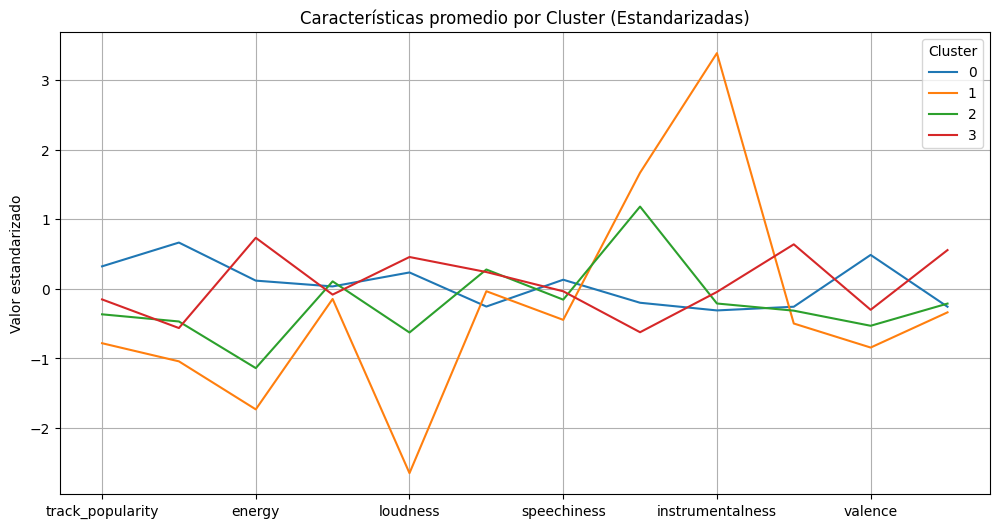

In [ ]:
# Visualización de las características promedio por cluster (Estandarizadas)

datos_std = pd.DataFrame(datos_escalados, columns=columnas)
datos_std["Cluster"] = clusters
promedios_std = datos_std.groupby("Cluster").mean()

promedios_std.T.plot(figsize=(12,6))

plt.title("Características promedio por Cluster (Estandarizadas)")
plt.ylabel("Valor estandarizado")
plt.grid(True)

plt.show()

In [ ]:
# Analizar las características promedio de cada cluster
datos.groupby("Cluster").mean().round(2)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,67.15,0.72,0.69,5.37,-6.10,0.49,0.10,0.21,0.00,0.15,0.63,114.95
1,40.79,0.44,0.30,4.72,-19.01,0.60,0.05,0.75,0.84,0.12,0.32,112.68
2,50.70,0.53,0.42,5.63,-9.97,0.75,0.08,0.61,0.03,0.14,0.39,116.21
3,55.81,0.52,0.81,4.95,-5.11,0.73,0.09,0.09,0.06,0.28,0.45,137.76


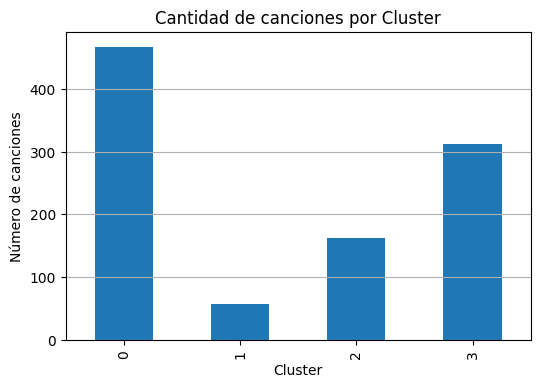

Cluster
0    468
1     57
2    163
3    312
Name: count, dtype: int64

In [26]:
# Visualización de la cantidad de canciones por cluster
plt.figure(figsize=(6,4))

datos["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Cantidad de canciones por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de canciones")

plt.grid(axis="y")

plt.show()
datos["Cluster"].value_counts().sort_index()

Cluster 0: Canciones populares y bailables

Este grupo reúne las canciones con mayor popularidad promedio (67.15). Se caracterizan por tener una alta capacidad para bailar (danceability = 0.72), buena energía (0.69) y un nivel de volumen relativamente alto (-6.10 dB). Además, presentan un nivel moderado de valencia (0.63), lo que indica canciones con un sonido más positivo y alegre. Este cluster representa canciones comerciales y muy atractivas para el público.

Cluster 1: Canciones acústicas e instrumentales

Este cluster presenta la menor popularidad (40.79). Se distingue por tener una alta acousticness (0.75) y un instrumentalness muy elevado (0.84), además de una energía baja (0.30) y el volumen más bajo (-19.01 dB). Estas características indican que corresponde principalmente a canciones tranquilas, acústicas o instrumentales, orientadas a un público más específico.

Cluster 2: Canciones equilibradas

Las canciones de este grupo muestran valores intermedios en la mayoría de las variables. Poseen una energía moderada (0.42), una acousticness relativamente alta (0.61) y una popularidad media (50.70). Este cluster representa canciones con un perfil equilibrado, que combinan elementos acústicos con características modernas sin destacar de forma extrema en ninguna variable.

Cluster 3: Canciones muy enérgicas y rápidas

Este grupo se caracteriza por tener la mayor energía (0.81) y el tempo más alto (137.76 BPM). También presenta el volumen más alto (-5.11 dB) y una popularidad relativamente elevada (55.81). Estas características corresponden a canciones intensas, rápidas y dinámicas, ideales para actividades como fiestas, ejercicio o música electrónica.

En este taller se aplicó un proceso completo de aprendizaje no supervisado para identificar patrones musicales en un conjunto de canciones de Spotify. Inicialmente se realizó la limpieza y estandarización de los datos, seleccionando únicamente las características acústicas de las canciones para evitar sesgos relacionados con el artista o el género musical. Posteriormente, se aplicó el Análisis de Componentes Principales (PCA), lo que permitió reducir la dimensionalidad de los datos y facilitar su visualización en dos dimensiones. Finalmente, se utilizó el algoritmo K-Means para generar cuatro clusters, identificando grupos de canciones con características similares en términos de popularidad, energía, ritmo y propiedades acústicas. Aunque el Silhouette Score obtenido fue moderado, los clusters resultaron interpretables y evidenciaron la existencia de patrones naturales entre las canciones. Este tipo de técnicas demuestra cómo el aprendizaje no supervisado puede ser utilizado para segmentar contenido musical y contribuir al desarrollo de sistemas de recomendación más precisos en plataformas de streaming.